### Referrel Porgram A/B Analysis
End-to-end analysis of a user referral program using Python and pandas — evaluating pre/post launch impact on user growth, transaction volume, and revenue with actionable recommendations for the Growth team.

#### Step 1 — Import Libraries
Import all required libraries for data manipulation (`pandas`, `numpy`), statistical testing (`scipy`, `statsmodels`), visualization (`matplotlib`, `seaborn`), and file path handling (`os`).

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import os
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

#### Step 2 — Load the Dataset
Read the referral CSV file from the `data/` directory into a pandas DataFrame and preview the first few rows to confirm the data loaded correctly.

In [45]:
referral  = pd.read_csv(os.path.join('data', 'referral.csv'))
referral.head()

,user_id,date,country,money_spent,is_referral,device_id
0,2,2015-10-03,FR,65,0,EVDCJTZMVMJDG
1,3,2015-10-03,CA,54,0,WUBZFTVKXGQQX
2,6,2015-10-03,FR,35,0,CBAPCJRTFNUJG
3,7,2015-10-03,UK,73,0,PRGXJZAJKMXRH
4,7,2015-10-03,MX,35,0,PRGXJZAJKMXRH


#### Step 3 — Inspect Data Types and Non-Null Counts
Print a structural summary of the DataFrame including column names, data types, and the count of non-null values — useful for spotting missing data early.

In [46]:
print('Dataset Information:', referral.info())

<class 'pandas.DataFrame'>
RangeIndex: 97341 entries, 0 to 97340
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      97341 non-null  int64
 1   date         97341 non-null  str  
 2   country      97341 non-null  str  
 3   money_spent  97341 non-null  int64
 4   is_referral  97341 non-null  int64
 5   device_id    97341 non-null  str  
dtypes: int64(3), str(3)
memory usage: 4.5 MB
Dataset Information: None


#### Step 4 — Summary Statistics
Generate descriptive statistics (mean, std, min, max, quartiles) across all numeric columns to understand the distribution and scale of key variables like `money_spent`.

In [47]:
print('Dataset Description:\n', referral.describe())

Dataset Description:
             user_id   money_spent   is_referral
count  97341.000000  97341.000000  97341.000000
mean    6354.801029     44.692360      0.287823
std     5682.991186     22.791839      0.452751
min        1.000000     10.000000      0.000000
25%     2020.000000     27.000000      0.000000
50%     4053.000000     42.000000      0.000000
75%    10286.000000     59.000000      1.000000
max    20000.000000    220.000000      1.000000


#### Step 5 — Check for Duplicate Rows
Identify fully duplicate rows where every column value is identical, count them, and display them to assess the extent of data quality issues before cleaning.

In [104]:
print('Dataset Duplicates:', referral.duplicated(keep=False).sum())
# Display duplicate rows
print(referral[referral.duplicated(keep=False)].head(10))

Dataset Duplicates: 2
       user_id       date country  money_spent  is_referral      device_id  \
68047    11858 2015-11-10      US           21            0  RCUQILGCQNAIH   
68048    11858 2015-11-10      US           21            0  RCUQILGCQNAIH   

              period  
68047  Post-Referral  
68048  Post-Referral  


#### Step 6 — Isolate Referral Duplicates
Narrow the duplicate check to rows where `is_referral = 1` to determine whether referred user records specifically are being double-counted, which could inflate the treatment group.

In [103]:
print('Dataset Duplicates with is_referral=1:', (referral.duplicated(keep=False) & (referral['is_referral']==1)).sum())
print(referral[referral.duplicated(keep=False) & (referral['is_referral']==1)])

Dataset Duplicates with is_referral=1: 0
Empty DataFrame
Columns: [user_id, date, country, money_spent, is_referral, device_id, period]
Index: []


#### Step 7 — Referral Class Distribution
Calculate the proportion of referral vs. non-referral transactions using normalized value counts to understand the class balance across the full dataset.

In [50]:
print('referral distribution:\n', referral['is_referral'].value_counts(normalize=True))

referral distribution:
 is_referral
0    0.712177
1    0.287823
Name: proportion, dtype: float64


#### Step 8 — Spending Distribution by Referral Status (Mid-Range Band)
Cross-tabulate referral status against a mid-range spend band ($50–$100) to examine whether referred and non-referred users cluster differently within that spend tier.

In [51]:
pd.crosstab(referral['is_referral'], referral[(referral['money_spent'] > 50) & (referral['money_spent'] < 100)]['money_spent']
            ,normalize='index'
            ).round(2)

money_spent,51,52,53,54,55,56,57,58,59,60,...,90,91,92,93,94,95,96,97,98,99
is_referral,,,,,,,,,,,,,,,,,,,,,
0,0.05,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.03,0.03,...,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00
1,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.03,0.03,0.03,...,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01


#### Step 9 — Remove Duplicate Rows
Drop all fully duplicate rows identified in the earlier checks. This ensures each transaction is counted exactly once, keeping the dataset clean for downstream analysis.

In [52]:
referral = referral.drop_duplicates()

#### Step 10 — Verify Referral Distribution Post-Deduplication
Re-check the referral/non-referral split after removing duplicates to confirm the class balance has not materially shifted and the cleaned dataset is still representative.

In [69]:
print('Re check referral distribution:\n', referral['is_referral'].value_counts(normalize=True))

Re check referral distribution:
 is_referral
0    0.710914
1    0.289086
Name: proportion, dtype: float64


#### Step 11 — Fix `is_referral` Consistency Per User

A user who has multiple transactions should carry the **same** `is_referral` label across all rows — either they came from the referral program or they didn't. Inconsistent flags per user (e.g. one row with `1` and another with `0`) would corrupt both the treatment/control group assignment and the hypothesis tests.

To fix this:
1. **Sort** the DataFrame by `user_id` and `date` so the earliest transaction appears first.
2. **Propagate** the first observed `is_referral` value for each user to all of their subsequent rows using `groupby` + `transform('first')`.
3. **Verify** that every user now has exactly one unique `is_referral` value — the `.max()` should return `1`.

In [70]:
 #Sort by user and date first
referral = referral.sort_values(['user_id', 'date'])

# Now assign first is_referral value per user
referral['is_referral'] = referral.groupby('user_id')['is_referral'].transform('first')

# Verify
print(referral.groupby('user_id')['is_referral'].nunique().max())
# Should return 1

1


#### Step 12 — Parse the Date Column & Inspect Date Range
Convert the `date` column from a string to a proper `datetime64` type, then confirm the minimum and maximum dates to understand the full time window covered by the dataset.

In [79]:
referral['date'] = pd.to_datetime(referral['date'])
referral['date'].max(), referral['date'].min()  

(Timestamp('2015-11-27 00:00:00'), Timestamp('2015-10-03 00:00:00'))

#### Step 13 — Split Into Pre- and Post-Launch Periods
Partition the cleaned dataset into two subsets using the program launch date of October 31, 2015 as the cut-off — `df_pre` for before launch and `df_post` for on or after launch.

In [80]:
df_pre = referral[referral['date'] < '2015-10-31']
df_post = referral[referral['date'] >= '2015-10-31']

#### Step 14 — Aggregate Pre-Launch Daily Metrics
Group the pre-launch data by referral status and date, computing three daily metrics per group: unique user count (`total_users`), total revenue (`total_spent`), and average spend (`avg_spent`).

In [81]:
control_pre = df_pre.groupby(['is_referral', 'date'])\
    .agg(total_users=('user_id', 'nunique'),
         total_spent=('money_spent', 'sum'),
         avg_spent=('money_spent', 'mean'))\
    .reset_index()



#### Step 15 — Aggregate Post-Launch Daily Metrics by Group
Separately aggregate the post-launch data for the **control group** (`is_referral = 0`) and the **treatment group** (`is_referral = 1`) using the same daily metrics, so they can be compared directly in subsequent analysis.

In [82]:
control_post = df_post[df_post['is_referral']==0].groupby(['is_referral', 'date'])\
    .agg(total_users=('user_id', 'nunique'),
         total_spent=('money_spent', 'sum'),
         avg_spent=('money_spent', 'mean'))\
    .reset_index()
test_post = df_post[df_post['is_referral']==1].groupby(['is_referral', 'date'])\
    .agg(total_users=('user_id', 'nunique'),
         total_spent=('money_spent', 'sum'),
         avg_spent=('money_spent', 'mean'))\
    .reset_index()

#### Step 16 — Visualise Average Spend Over Time (Pre vs Post)
Plot two line charts stacked vertically — one for the pre-launch period and one for the post-launch period — comparing daily average spend between referral and non-referral users to spot any divergence in spending behaviour after the program launched.

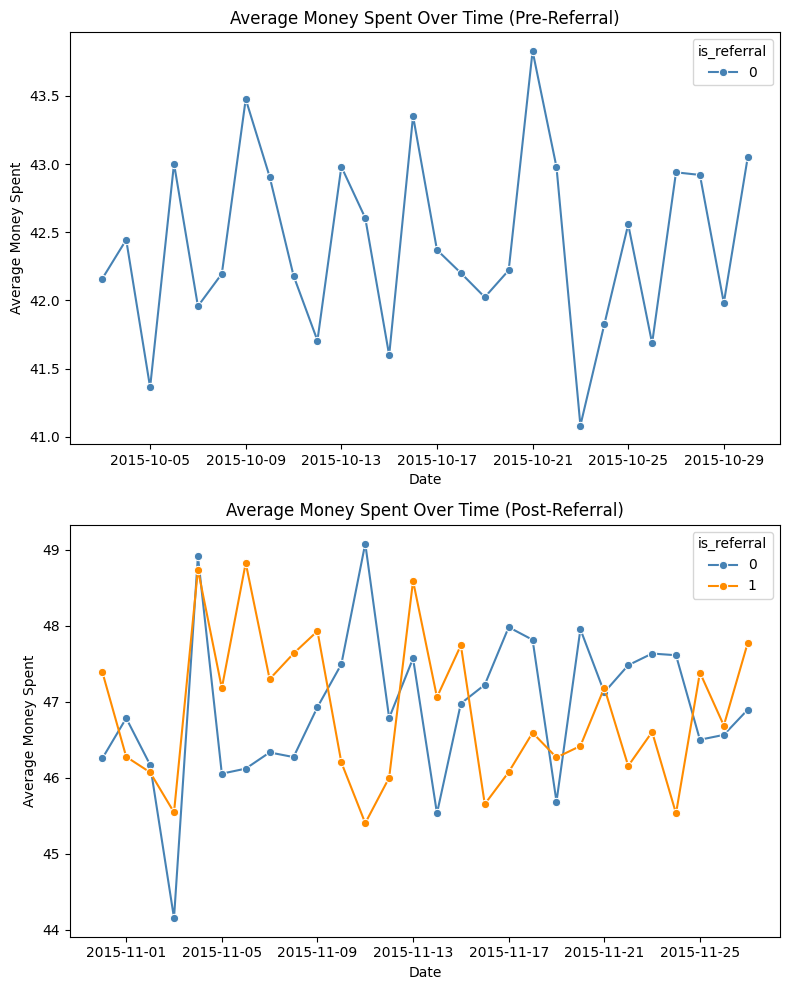

In [83]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Top subplot - Pre-Referral
sns.lineplot(data=control_pre, x='date', y='avg_spent', hue='is_referral', marker='o',
             palette={0: 'steelblue', 1: 'darkorange'}, ax=axes[0])
axes[0].set_title('Average Money Spent Over Time (Pre-Referral)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average Money Spent')

# Bottom subplot - Post-Referral (combine control and test)
post_combined = pd.concat([control_post, test_post])
sns.lineplot(data=post_combined, x='date', y='avg_spent', hue='is_referral', marker='o',
             palette={0: 'steelblue', 1: 'darkorange'}, ax=axes[1])
axes[1].set_title('Average Money Spent Over Time (Post-Referral)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Money Spent')

plt.tight_layout()
plt.show()

#### Step 17 — Device vs User Count Over Time
Plot daily unique device count against daily unique user count across the full timeline, with a vertical line at the program launch date. A crossover where users exceed devices post-launch is a red flag for multi-account fraud or cannibalization of existing users exploiting the $10 referral credit.

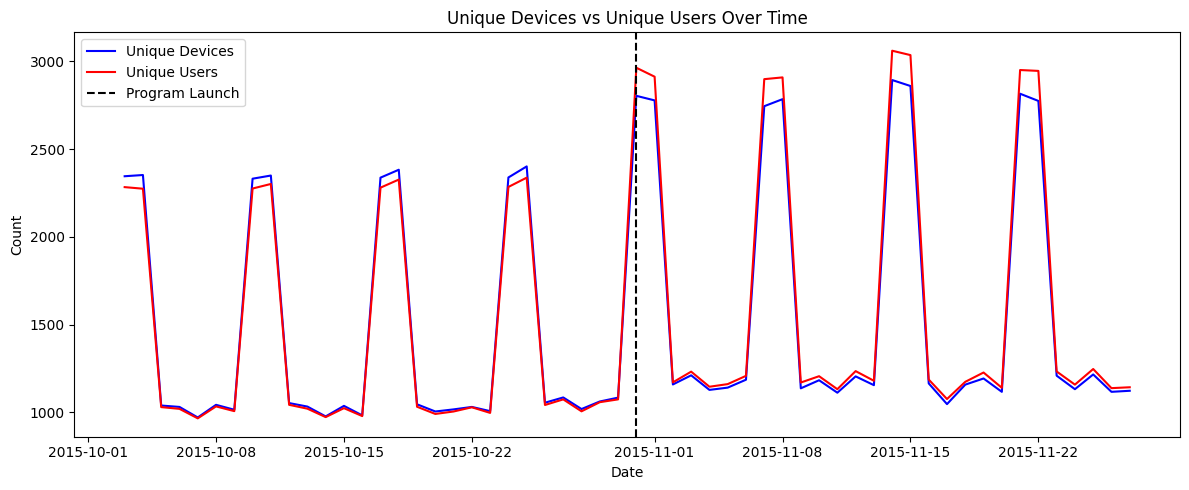

In [74]:
# Compare unique devices vs unique users over time
plt.figure(figsize=(12, 5))
plt.plot(referral.groupby('date')['device_id'].nunique(), color='blue', label='Unique Devices')
plt.plot(referral.groupby('date')['user_id'].nunique(), color='red', label='Unique Users')
plt.axvline(pd.Timestamp('2015-10-31'), color='black', linestyle='--', label='Program Launch')
plt.title('Unique Devices vs Unique Users Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

- Pre-launch: unique devices exceeded unique users — expected behavior.
- Post-launch: unique users exceeded unique devices — suggests multiple accounts 
per device, indicating potential fraud or cannibalization of existing users 
exploiting the $10 referral credit.

**This likely explains why referred users showed no meaningful spend lift — many "referred" users may be existing users, not genuinely new customers.**

#### Step 18 — Referral Adoption Rate by Country
Plot the mean referral rate per country as a bar chart to identify which geographic markets have the highest and lowest referral program participation rates.

/var/folders/2w/kp8gz8v954g0xmwktm0mw5vr0000gn/T/ipykernel_44122/164185732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=referral, x='country', y='is_referral', estimator='mean', errorbar=None, palette='viridis')


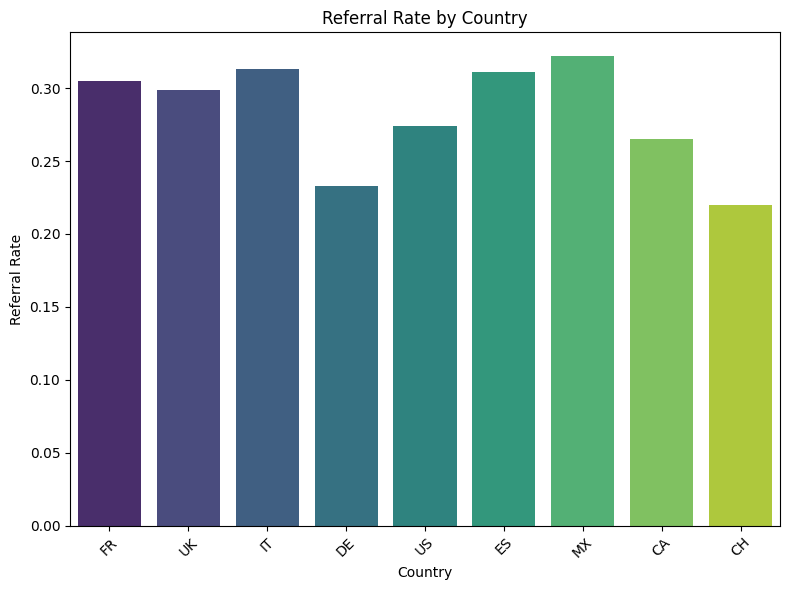

In [84]:
plt.figure(figsize=(8, 6))
sns.barplot(data=referral, x='country', y='is_referral', estimator='mean', errorbar=None, palette='viridis')
plt.title('Referral Rate by Country')
plt.xlabel('Country')
plt.ylabel('Referral Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

#### Step 19 — Average Spend by Country and Referral Status (Post-Launch)
For the post-launch period, plot average `money_spent` broken down by country and referral status side by side, to identify markets where the referral program had the greatest (or least) monetary impact.

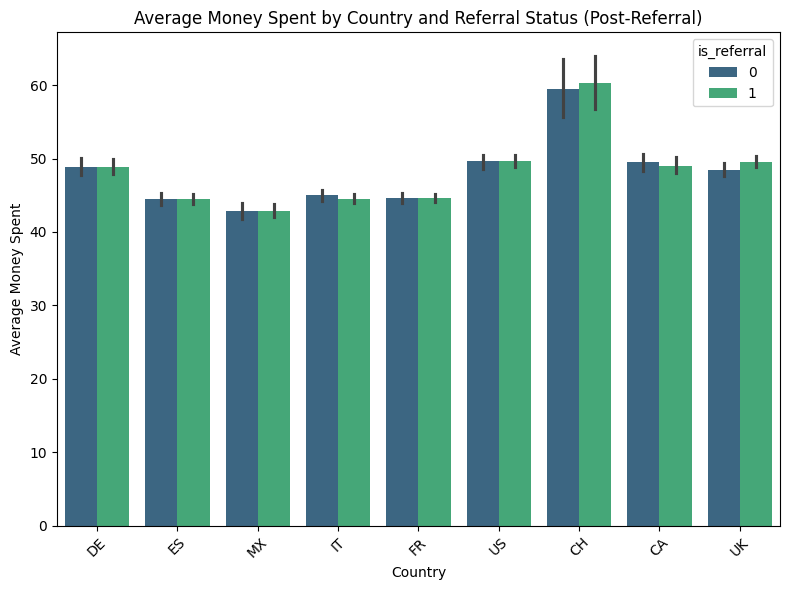

In [85]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df_post, x='country', y='money_spent', hue='is_referral', palette='viridis')
plt.title('Average Money Spent by Country and Referral Status (Post-Referral)')
plt.xlabel('Country')
plt.ylabel('Average Money Spent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Hypothesis 1 — Spend

- H₀: Mean money spent is equal for referral and non-referral users
- H₁: Mean money spent is greater for referral users

#### Step 20 — Statistical Test for H1 (Spend)
Run a one-tailed independent samples t-test (`alternative='greater'`) comparing `money_spent` between referred and non-referred users in the post-launch period. A p-value below 0.05 would indicate that referred users spent significantly more.

In [86]:
referral_spend = df_post[df_post['is_referral']==1]['money_spent']
non_referral_spend = df_post[df_post['is_referral']==0]['money_spent']

# Hypothesis 1


t_stat, p_value = stats.ttest_ind(referral_spend, non_referral_spend, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀ — Mean money spent is significantly higher for referrals")
else:
    print("Fail to reject H₀ — No significant spend increase detected")


T-statistic: 0.5961
P-value: 0.2756
Fail to reject H₀ — No significant spend increase detected


#### Step 21 — Compute Incremental Spend (Referral vs Non-Referral)
Calculate the raw dollar difference in average `money_spent` between referred and non-referred users in the post-launch period. This translates the H1 t-test result into a concrete business number — the incremental revenue per referral transaction that must be weighed against the $10 credit cost.

In [92]:
avg_spend_referral = df_post[df_post['is_referral']==1]['money_spent'].mean()
avg_spend_non_referral = df_post[df_post['is_referral']==0]['money_spent'].mean()
incremental = avg_spend_referral - avg_spend_non_referral
print(f"Incremental spend (referral vs non-referral): ${incremental:.2f}")

Incremental spend (referral vs non-referral): $0.13


### H1 Result
##### t=0.596, p=0.275 — Fail to reject H₀
- Referred users show no significant spend advantage over non-referred users.
- The $0.13 incremental spend cannot justify the $10 credit cost.

### Hypothesis 2 — User Growth

- H₀: Mean daily unique users before Oct 31 = mean daily unique users after Oct 31
- H₁: Mean daily unique users increased after Oct 31

#### Step 22 — Statistical Test for H2 (User Growth)
Compute daily unique user counts for the pre- and post-launch periods, then apply a one-tailed t-test to determine whether mean daily active users increased significantly after the referral program launched.

In [87]:
pre_daily = df_pre.groupby('date')['user_id'].nunique()
post_daily = df_post.groupby('date')['user_id'].nunique()
# Hypothesis 2
t_stat, p_value = stats.ttest_ind(post_daily, pre_daily, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀ — Daily active users significantly increased after launch")
else:
    print("Fail to reject H₀ — No significant increase in daily active users detected")

T-statistic: 1.5864
P-value: 0.0592
Fail to reject H₀ — No significant increase in daily active users detected


#### H2 Result
##### t=1.586, p=0.059 — Fail to reject H₀
- User growth is trending upward post-launch but falls just short of significance.
- Likely a sample size issue — retest at 8-12 weeks for a conclusive result.

#### Hypothesis 3 — Overall Spend Lift

- H₀: Mean money spent per transaction before Oct 31 = after Oct 31
- H₁: Mean money spent per transaction increased after the referral progra

#### Step 23 — Statistical Test for H3 (Overall Spend Lift)
Isolate all `money_spent` values for the pre- and post-launch periods (regardless of referral status) and run a one-tailed t-test to determine if platform-wide average spend increased after the program launched.

In [88]:
pre_spend = df_pre['money_spent']
post_spend = df_post['money_spent']

t_stat, p_value = stats.ttest_ind(post_spend, pre_spend, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀ — Overall spend significantly increased after launch")
else:
    print("Fail to reject H₀ — No significant overall spend increase detected")

T-statistic: 30.8977
P-value: 0.0000
Reject H₀ — Overall spend significantly increased after launch


#### H3 Result
##### t=30.89, p≈0.000 — Reject H₀
- Overall spend increased significantly post-launch ($42.39 → $46.96).
- However, both referral and non-referral users lifted equally — seasonality likely the driver, not the program.

#### Confirming the Hypothesis 3 Result by visualizing

#### Step 24 — Visualise the Spend Lift (Pre vs Post)
Label each row with a `period` flag, then create a bar chart comparing mean `money_spent` across the pre- and post-launch periods to provide an intuitive visual of the magnitude of the spend difference identified in the H3 test.

/var/folders/2w/kp8gz8v954g0xmwktm0mw5vr0000gn/T/ipykernel_44122/178510506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


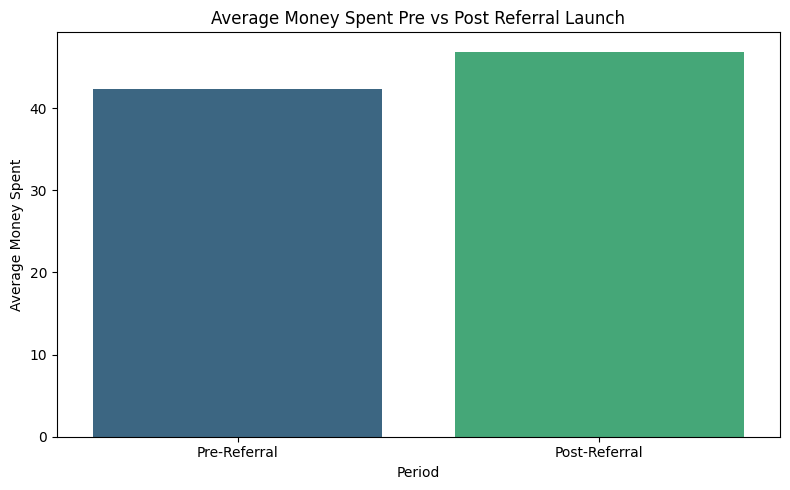

In [89]:
referral['period'] = referral['date']\
        .apply(lambda x: 'Pre-Referral' 
               if x < pd.to_datetime('2015-10-31') else 'Post-Referral')
plt.figure(figsize=(8, 5))
sns.barplot(
    data=referral, 
    x='period', 
    y='money_spent',
    palette='viridis',
    errorbar=None
)
plt.title('Average Money Spent Pre vs Post Referral Launch')
plt.xlabel('Period')
plt.ylabel('Average Money Spent')
plt.tight_layout()
plt.show()

#### Findings
- Overall spend increased significantly post-launch (p≈0.000, +$5 avg), but causality cannot be established without a control group. 
- November seasonality and concurrent factors likely contributed. 
- A properly designed A/B test is required before attributing this lift to the referral program or scaling the $10 credit incentive.

#### Step 25 — Prophet Forecast: Isolate Seasonality from Program Effect
Train a Facebook Prophet model on pre-launch daily revenue to establish a counterfactual baseline — "what would revenue have looked like without the program?". Forecast through the post-launch period, overlay the actual post-launch revenue, and run a paired t-test (actual vs predicted per day) to determine whether the lift is statistically significant beyond what the seasonal trend alone would predict.

07:50:34 - cmdstanpy - INFO - Chain [1] start processing
07:50:35 - cmdstanpy - INFO - Chain [1] done processing


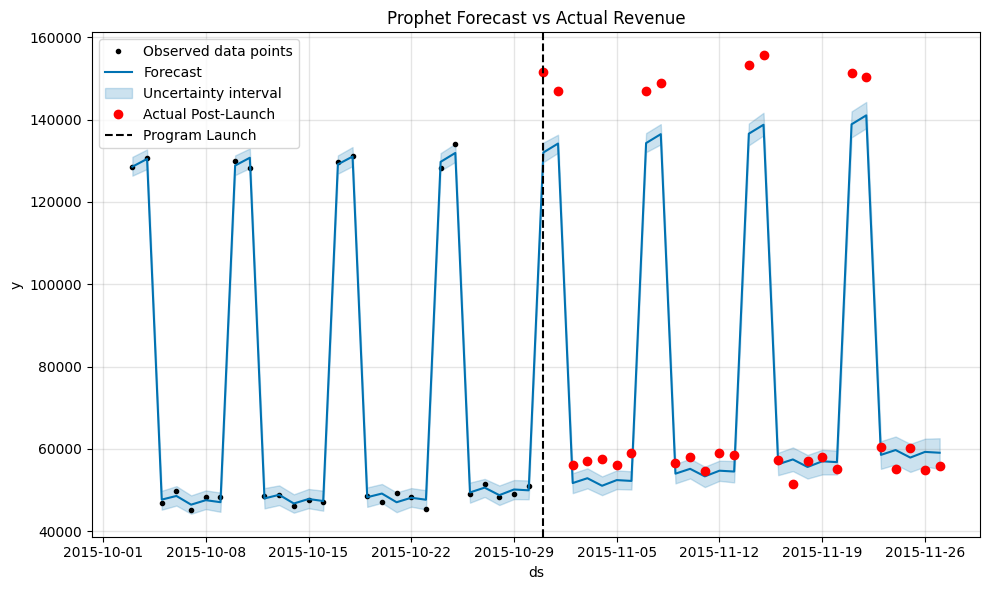

Mean actual revenue post-launch:    $83,710
Mean predicted revenue post-launch: $78,637
Difference:                         $5,073

Paired T-test — Actual vs Predicted
T-statistic: 3.9550
P-value: 0.0005


In [ ]:

# Prepare pre-launch data for training
data_prediction = referral.query('date < "2015-10-31"').groupby('date')['money_spent'].sum().reset_index()
data_prediction.columns = ['ds', 'y']

# Build and fit model
model = Prophet(interval_width=0.95)
model.fit(data_prediction)

# Forecast through end of dataset
days_ahead = (referral['date'].max() - data_prediction['ds'].max()).days
future = model.make_future_dataframe(periods=days_ahead)
forecast = model.predict(future)

# Plot predicted vs actual
fig = model.plot(forecast)
plt.plot(
    referral.query('date > "2015-10-30"').groupby('date')['money_spent'].sum(),
    'o', color='red', label='Actual Post-Launch'
)
plt.axvline(pd.Timestamp('2015-10-31'), color='black', linestyle='--', label='Program Launch')
plt.title('Prophet Forecast vs Actual Revenue')
plt.legend()
plt.tight_layout()
plt.show()

# Compare means
predicted_mean = forecast.query('ds > "2015-10-30"')['yhat'].mean()
actual_mean = referral.query('date > "2015-10-30"').groupby('date')['money_spent'].sum().mean()
print(f"Mean actual revenue post-launch:    ${actual_mean:,.0f}")
print(f"Mean predicted revenue post-launch: ${predicted_mean:,.0f}")
print(f"Difference:                         ${actual_mean - predicted_mean:,.0f}")

# Paired t-test: actual vs predicted day by day
actual_daily = referral.query('date > "2015-10-30"').groupby('date')['money_spent'].sum()
predicted_daily = forecast.query('ds > "2015-10-30"').set_index('ds')['yhat']
predicted_daily.index = predicted_daily.index.normalize()

t_stat, p_value = stats.ttest_rel(actual_daily, predicted_daily)
print(f"\nPaired T-test — Actual vs Predicted")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

### Prophet Forecast Result
##### t=3.955, p=0.0005 — Actual revenue significantly exceeded forecast

- Actual post-launch revenue averaged $83,710/day vs predicted $78,637/day
- Daily lift of ~$5,073 is statistically significant and consistently above 
  the 95% confidence interval
- However, with only 28 days of training data, Prophet cannot account for 
  November seasonality — this lift may be partially or fully explained by 
  holiday spending patterns rather than the referral program

#### Step 26 — Stationarity Check (Augmented Dickey-Fuller Test)
Before fitting an ARIMA model, the time series must be checked for stationarity — a constant mean and variance over time. The ADF test returns a p-value: if p < 0.05 the series is stationary (d=0); otherwise differencing is required (d=1). This result directly determines the `d` parameter passed to ARIMA.

In [94]:
from statsmodels.tsa.stattools import adfuller

# Prepare daily revenue series
daily_revenue = referral.query('date < "2015-10-31"').groupby('date')['money_spent'].sum()

# Augmented Dickey-Fuller test
result = adfuller(daily_revenue)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"P-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("Series is stationary — good to go with ARIMA")
else:
    print("Series is non-stationary — needs differencing (d=1)")

ADF Statistic: 2.0793
P-value: 0.9988
Series is non-stationary — needs differencing (d=1)


#### Step 27 — Fit ARIMA(1,1,1) Model on Pre-Launch Revenue
Fit an ARIMA model with order (1,1,1) on the pre-launch daily revenue series — `d=1` because the ADF test indicated non-stationarity. Print the model summary to inspect coefficient estimates, standard errors, and information criteria (AIC/BIC) which can be used to validate the chosen order.

In [ ]:


# Prepare pre-launch daily revenue
daily_revenue = referral.query('date < "2015-10-31"').groupby('date')['money_spent'].sum()

# Fit ARIMA(1,1,1) - d=1 because non-stationary
model_arima = ARIMA(daily_revenue, order=(1,1,1))
result_arima = model_arima.fit()
print(result_arima.summary())


                               SARIMAX Results                                
Dep. Variable:            money_spent   No. Observations:                   28
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -322.019
Date:                Tue, 26 May 2026   AIC                            650.038
Time:                        07:56:34   BIC                            653.926
Sample:                    10-03-2015   HQIC                           651.194
                         - 10-30-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3642      0.490      0.743      0.458      -0.597       1.325
ma.L1         -0.9627      0.727     -1.324      0.185      -2.387       0.462
sigma2      1.768e+09   5.95e-10   2.97e+18      0.0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


#### Step 28 — ARIMA Forecast vs Actual Revenue (Plot)
Use the fitted ARIMA model to forecast daily revenue for the post-launch period and plot it alongside the actual pre- and post-launch revenue series. The gap between the green forecast line and the red actual line represents the unexplained lift — whether that is from the referral program, seasonality, or other factors.

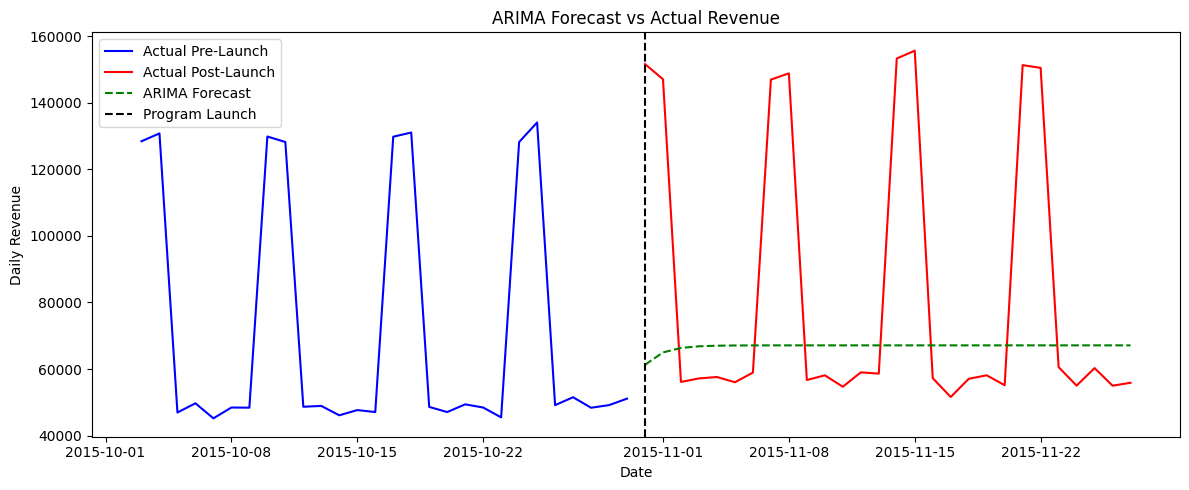

In [96]:
# Forecast post-launch period
days_ahead = (referral['date'].max() - daily_revenue.index.max()).days
forecast_arima = result_arima.forecast(steps=days_ahead)

# Plot predicted vs actual
plt.figure(figsize=(12, 5))
plt.plot(daily_revenue.index, daily_revenue, color='blue', label='Actual Pre-Launch')
plt.plot(
    referral.query('date > "2015-10-30"').groupby('date')['money_spent'].sum(),
    color='red', label='Actual Post-Launch'
)
plt.plot(forecast_arima.index, forecast_arima, color='green', 
         linestyle='--', label='ARIMA Forecast')
plt.axvline(pd.Timestamp('2015-10-31'), color='black', 
            linestyle='--', label='Program Launch')
plt.title('ARIMA Forecast vs Actual Revenue')
plt.xlabel('Date')
plt.ylabel('Daily Revenue')
plt.legend()
plt.tight_layout()
plt.show()


#### Step 29 — Compare ARIMA Predicted vs Actual Mean Revenue
Print the mean daily revenue for the actual post-launch period against the ARIMA model's forecast mean for the same window. The difference quantifies the average daily lift, providing a complementary dollar-value metric alongside the Prophet result.

In [97]:
# Compare means
actual_mean = referral.query('date > "2015-10-30"').groupby('date')['money_spent'].sum().mean()
arima_mean = forecast_arima.mean()
print(f"Mean actual revenue post-launch:    ${actual_mean:,.0f}")
print(f"Mean ARIMA forecast post-launch:    ${arima_mean:,.0f}")
print(f"Difference:                         ${actual_mean - arima_mean:,.0f}")

Mean actual revenue post-launch:    $83,710
Mean ARIMA forecast post-launch:    $66,781
Difference:                         $16,929


### ARIMA(1,1,1) Forecast Result
- ARIMA predicted avg daily revenue of $66,781 vs actual $83,710 (+$16,929)
- However ARIMA flattened the weekly seasonality pattern, underestimating 
  the baseline — making the lift appear larger than it likely is
- Prophet is the more reliable model here due to built-in weekly seasonality
- Both models agree on direction: actual revenue exceeded forecast post-launch
- Limitation: 28 days of training data is insufficient for either model to 
  fully capture seasonal patterns

#### Step 30 — Cost-Benefit Analysis
Quantify the financial reality of the referral program: calculate total credit spend, average spend per group (pre-launch, referral, non-referral), the incremental spend per referral transaction, and the net return after accounting for the $10 credit cost.

In [90]:
referral_transactions = df_post['is_referral'].sum()
total_credit_cost = referral_transactions * 10

avg_spend_referral = df_post[df_post['is_referral']==1]['money_spent'].mean()
avg_spend_non_referral = df_post[df_post['is_referral']==0]['money_spent'].mean()
avg_spend_pre_referral = df_pre['money_spent'].mean()
incremental_spend = avg_spend_referral - avg_spend_non_referral

print(f"Total referral transactions: {referral_transactions:,.0f}")
print(f"Total credit cost: ${total_credit_cost:,.0f}")
print(f"Avg spend - Pre-referral: ${avg_spend_pre_referral:.2f}")
print(f"Avg spend - Referral users: ${avg_spend_referral:.2f}")
print(f"Avg spend - Non-referral users: ${avg_spend_non_referral:.2f}")
print(f"Incremental spend per referral: ${incremental_spend:.2f}")
print(f"Net per referral transaction: ${incremental_spend - 10:.2f}")

Total referral transactions: 28,133
Total credit cost: $281,330
Avg spend - Pre-referral: $42.39
Avg spend - Referral users: $46.94
Avg spend - Non-referral users: $46.81
Incremental spend per referral: $0.13
Net per referral transaction: $-9.87


#### Findings
- The referral program cost $281,330 in credits during its first month. 
- Referred users spent only $0.13 more per transaction than non-referred users, resulting in a net loss of $9.87 per referral transaction. 
- The program cannot be justified on spend lift alone and requires user retention and lifetime value analysis before scaling.

#### Step 31 — Daily Transaction Volume — Pre vs Post Launch
Group the full dataset by date and period label, count daily transactions, and plot a line chart across the entire timeline. A vertical red dashed line marks the October 31 launch date to make the volume shift visually clear.

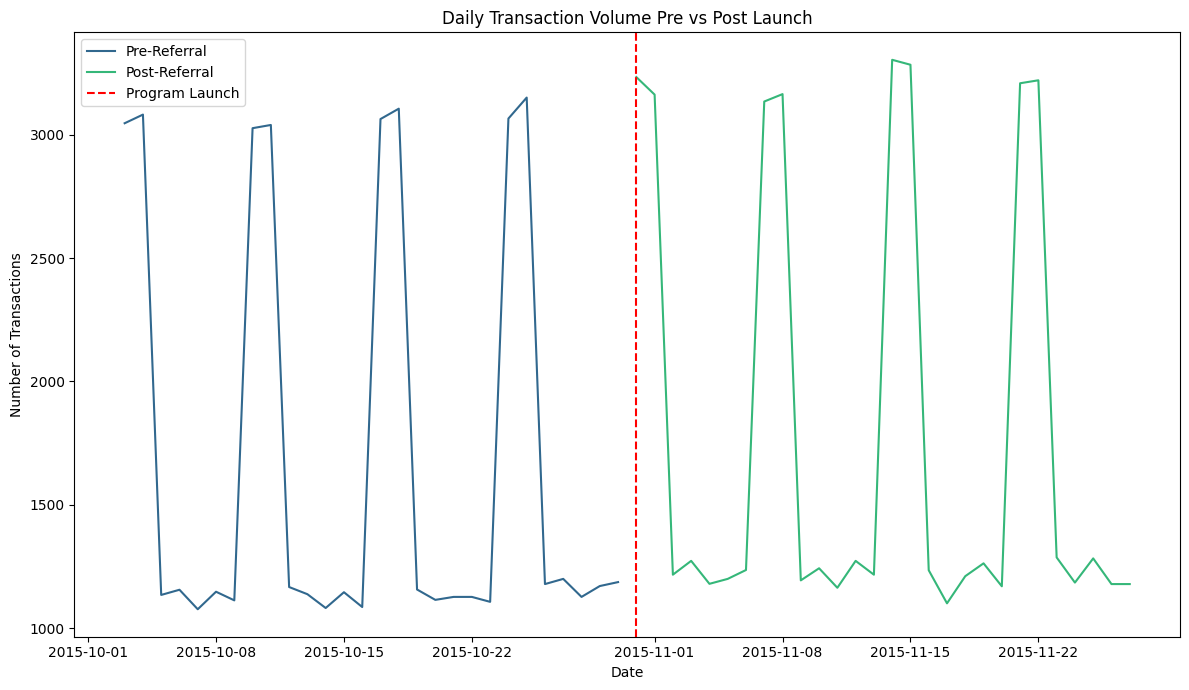

In [91]:
daily_volume = referral.groupby(['date', 'period'])['user_id'].count().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=daily_volume, x='date', y='user_id', hue='period', palette='viridis')
plt.axvline(pd.Timestamp('2015-10-31'), color='red', linestyle='--', label='Program Launch')
plt.title('Daily Transaction Volume Pre vs Post Launch')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Conclusion & Recommendations

### What the Data Tells Us
The referral program launched on October 31, 2015 shows mixed results after its 
first month. While overall platform spend increased significantly post-launch, 
multiple analyses suggest external factors such as November seasonality are 
contributing to the lift. More critically, device analysis revealed signs of 
fraudulent activity, undermining the program's reported user growth.

### Key Findings

1. **Referred users do not spend more** — Referred users spent only $0.13 more 
   per transaction than non-referred users (t=0.596, p=0.275). Statistically 
   insignificant and insufficient to justify the $10 credit cost.

2. **Program is running at a loss** — Total credit cost reached $281,330 in the 
   first month with a net loss of $9.87 per referral transaction.

3. **User growth is promising but unconfirmed** — Daily unique users trended 
   upward post-launch (t=1.586, p=0.059) but fell just short of statistical 
   significance, likely due to only 4 weeks of post-launch data.

4. **Overall spend lifted significantly** — Platform-wide avg spend rose from 
   $42.39 to $46.96 (p≈0.000). Prophet forecasting confirmed this — actual 
   revenue averaged $83,710/day vs predicted $78,637/day (t=3.955, p=0.0005). 
   However both referral and non-referral users lifted equally, and November 
   seasonality cannot be ruled out as the primary driver.

5. **Fraud/Cannibalization detected** — Post-launch, unique users exceeded unique 
   devices — a reversal of the pre-launch pattern. This strongly suggests existing 
   users created new accounts to exploit the $10 credit, explaining why referred 
   users show no meaningful spend advantage over organic users.

6. **Country insights** — IT, MX, ES, and FR showed highest referral adoption 
   (~31%). DE and CH underperformed (~23%) despite being high-value markets.

### Recommendations

1. **Do not scale the program** — The $10 credit is not justified by spend data 
   alone. Consider reducing to $5 or making it conditional on the referred user's 
   second purchase to improve unit economics.

2. **Address fraud immediately** — Implement device fingerprinting or phone 
   verification to prevent existing users from creating multiple accounts to 
   claim referral credits. This is the most urgent action item.

3. **Run a proper A/B test** — Current analysis cannot isolate program impact 
   from seasonal factors. Randomly assign a control group before any further 
   investment in the program.

4. **Retest user growth at 8–12 weeks** — The borderline p=0.059 result needs 
   more data. A longer window will determine if user growth is a real program 
   effect or noise.

5. **Analyze lifetime value** — Referred users may retain better or purchase 
   more frequently over time. LTV analysis could justify the $10 credit even 
   without a per-transaction spend lift.

6. **Target high-adoption markets** — Double down on IT, MX, ES, and FR. 
   Investigate barriers in DE and CH through localized incentive testing.

7. **Test alternative incentive structures** — Explore tiered credits, dual-sided 
   rewards, or non-monetary incentives to improve unit economics without 
   sacrificing growth.